# JiT-S/2 on CIFAR-10 — Stripped: No In-Context Tokens, No CFG

**Paper:** [Back to Basics: Let Denoising Generative Models Denoise](https://arxiv.org/abs/2511.13720) (Li & He, 2025)  
**Repo:** [LTH14/JiT](https://github.com/LTH14/JiT)

A minimal-ablation variant of JiT-S/2 with two paper components **permanently removed from the code**:

1. **No in-context class tokens.** Class conditioning happens only through the adaLN-Zero path (the standard DiT-style conditioning), exactly like in the original `model_jit.py` when `in_context_len=0`. The `in_context_posemb` parameter, the second `feat_rope_incontext` RoPE instance, and the prepend/strip logic in `forward()` are all gone. The class signature has no `in_context_*` arguments.
2. **No CFG, no label dropout.** Training never replaces labels with a null class. Sampling does a single conditional forward pass per step — no unconditional pass, no CFG interval. The `Denoiser` constructor has no `cfg_scale`, `cfg_interval`, or `label_drop_prob` arguments, and `drop_labels()` is gone.

The rest of the architecture and recipe is identical to the faithful baseline: BottleneckPatchEmbed, RMSNorm, SwiGLU, QK-norm, 2D RoPE on q/k, adaLN-Zero conditioning, fixed 2D sin-cos posembed, middle-half dropout slot (unused at this size), x-prediction with v-loss, logit-normal `t`-sampler, Heun ODE sampler, dual EMA. The wrapper still mirrors `denoiser.py` structurally — it's just `denoiser.py` with the CFG-related code paths deleted.

**Expected impact on quality:**

- Removing in-context tokens cost the paper ~1.2 FID on JiT-B/16 (Table 4: 6.69 → 5.49 with in-context tokens; this ablation goes the other way).
- Removing CFG is the bigger loss. On JiT-L/16 in Figure 6, CFG takes FID from ~9 to 2.36. Expect this stripped run to look noticeably worse than the full version.

This is the right starting point if you want a clean baseline to A/B against the full model — or if you want to add other components (different conditioning schemes, etc.) without having to disentangle the in-context and CFG pieces first.


## 0. Configuration rationale (read this first)

The paper defines only four sizes — JiT-B, L, H, G — all evaluated on ImageNet at 256/512/1024. There's no JiT-S and no CIFAR config. The choices below are consistent with the paper's design principles where applicable, and are documented inline so you can see exactly where each number comes from.

**Architecture (after the two ablations: no in-context tokens, no CFG):**

| Knob | Value | Why |
|---|---|---|
| `input_size` | 32 | CIFAR-10 |
| `patch_size` | **2** | Gives sequence length `(32/2)² = 256` — same as paper's JiT-B/16 on ImageNet-256 |
| Raw patch dim | `2·2·3 = 12` | Tiny — much smaller than paper's 768 (B/16). The bottleneck patch embed still applies (`12 → 128 → 384`). |
| `depth` | 12 | Same as JiT-B |
| `hidden_size` | 384 | Half of JiT-B (768); matches DiT-S width for fair S-class compute |
| `num_heads` | 6 | Keeps `head_dim = 64`, same as JiT-B/L |
| `bottleneck_dim` | 128 | Paper Table 9: 128 for B/L |
| `mlp_ratio` | 4.0 | SwiGLU internally rescales by ×2/3 (paper convention) |
| `attn_drop`, `proj_drop` | 0.0 | Paper Table 9: 0 for B/L |
| `num_classes` | 10 | CIFAR-10 |
| in-context tokens | **removed** | Stripped in this notebook (the full version would have `in_context_len=32, in_context_start=4`, paper Table 9) |

**Flow / training hyperparameters (paper Table 9):**

| Knob | Value | Notes |
|---|---|---|
| `P_mean` | -0.8 | Logit-normal `t`-sampler mean |
| `P_std` | 0.8 | Logit-normal `t`-sampler std |
| `t_eps` | **0.05** | Paper's "clip of (1 − t) in division" — *not* 1e-3 |
| `noise_scale` | **1.0** | Paper's `1.0 × image_size / 256` rule was for SNR preservation going *up* to 512/1024 (where patch dim explodes). At CIFAR-32 the per-patch dim is 12 (tiny), so the failure mechanism that motivated the scaling doesn't apply. We use 1.0. |
| `label_drop_prob` | **0.0** | CFG is disabled in this notebook (paper Table 9 default is 0.1) |
| `cfg_scale` / `cfg_interval` | **removed** | CFG is disabled |
| `sampler` | heun | Paper Table 9 |
| `num_sampling_steps` | 50 | Paper Table 9 |
| EMA decays | **(0.9999, 0.9996)** | Defaults from `main_jit.py`. The paper keeps three (0.9996, 0.9998, 0.9999) and picks the best at inference. |

**Optimizer (paper Table 9 + `main_jit.py`):**

| Knob | Value | Why |
|---|---|---|
| optimizer | **AdamW**, β=(0.9, 0.95), wd=0 | Paper Table 9 says "Adam" but `main_jit.py` uses `torch.optim.AdamW` with `weight_decay=0` (mathematically identical to Adam at wd=0). We match the reference code. |
| lr rule | `actual_lr = blr × total_batch / 256` | From `main_jit.py`. Paper's `--blr 5e-5` on 8 GPUs × 128 = total batch 1024 → `actual_lr = 2e-4` (matches Table 9). |
| `PAPER_BLR` | 5e-5 | Paper's base lr |
| effective `PEAK_LR` at single-GPU batch 128 | **2.5e-5** | `5e-5 × 128 / 256` — the paper-faithful single-GPU value |
| warmup | 5 epochs | Paper Table 9 |
| schedule | constant after warmup | Paper Table 9 |
| epochs | 100 (default; **paper uses 200 for ablations, 600 for headline numbers**) | adjust as you have budget |
| batch size | 128 | Per-GPU batch in `main_jit.py` |
| data normalization | mean=0.5, std=0.5 → [-1, 1] | makes data ~unit variance per pixel, which is what `noise_scale=1.0` assumes |

**Checkpointing:** see Section 11b — `checkpoint-last.pt` every 5 epochs (resume target), `checkpoint-ep{N}.pt` every 25 epochs (archived), `checkpoint-best.pt` on every loss improvement.


## 1. Env setup


In [1]:
# Run ONCE per fresh kernel, then skip.
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "torch", "torchvision", "matplotlib", "tqdm", "numpy"])
print("Done. If torch was freshly installed, restart the kernel before continuing.")


Done. If torch was freshly installed, restart the kernel before continuing.


## 2. Imports


In [2]:
import math, copy, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
from tqdm import tqdm

print(f"✅ torch {torch.__version__}  |  torchvision {torchvision.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✅ torch 2.10.0+cu128  |  torchvision 0.25.0+cu128
   Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 3. Primitives: RMSNorm, 2D sin-cos posembed, VisionRotaryEmbeddingFast

(Unchanged from the faithful baseline.)


In [3]:
# ─── RMSNorm ─────────────────────────────────────────────────────────────

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        x32 = x.float()
        norm = x32 * torch.rsqrt(x32.pow(2).mean(-1, keepdim=True) + self.eps)
        return (self.weight * norm).type_as(x)


# ─── 2D sin-cos positional embedding (DiT/MAE style) ─────────────────────

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    gh = np.arange(grid_size, dtype=np.float32)
    gw = np.arange(grid_size, dtype=np.float32)
    g = np.meshgrid(gw, gh)
    g = np.stack(g, axis=0).reshape([2, 1, grid_size, grid_size])
    emb_h = _get_1d_sincos(embed_dim // 2, g[0])
    emb_w = _get_1d_sincos(embed_dim // 2, g[1])
    return np.concatenate([emb_h, emb_w], axis=1)

def _get_1d_sincos(embed_dim, pos):
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.0
    omega = 1.0 / 10000**omega
    pos = pos.reshape(-1)
    out = np.einsum("m,d->md", pos, omega)
    return np.concatenate([np.sin(out), np.cos(out)], axis=1)


# ─── VisionRotaryEmbeddingFast (ported from EVA / LightningDiT) ──────────

def rotate_half(x):
    x = x.reshape(*x.shape[:-1], -1, 2)
    x1, x2 = x.unbind(dim=-1)
    return torch.stack((-x2, x1), dim=-1).reshape(*x.shape[:-2], -1)

def broadcat(tensors, dim=-1):
    return torch.cat(tensors, dim=dim)

class VisionRotaryEmbeddingFast(nn.Module):
    """
    2D factorized RoPE for ViT-style transformers.
    Ported from EVA: https://github.com/baaivision/EVA
    Used by LightningDiT and JiT.
    `num_cls_token` lets us skip the first N tokens (they don't get rotated).
    """
    def __init__(self, dim, pt_seq_len, ft_seq_len=None, theta=10000.0,
                 num_cls_token=0):
        super().__init__()
        if ft_seq_len is None:
            ft_seq_len = pt_seq_len

        self.num_cls_token = num_cls_token

        freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
        t = torch.arange(ft_seq_len) / ft_seq_len * pt_seq_len

        freqs_h = torch.outer(t, freqs)   # (H, dim/2)
        freqs_w = torch.outer(t, freqs)   # (W, dim/2)

        # Expand to 2D grid: token i = (h, w) gets (freqs_h[h], freqs_w[w])
        freqs_h = freqs_h[:, None, :].expand(ft_seq_len, ft_seq_len, -1)   # (H, W, dim/2)
        freqs_w = freqs_w[None, :, :].expand(ft_seq_len, ft_seq_len, -1)   # (H, W, dim/2)
        freqs = broadcat((freqs_h, freqs_w), dim=-1)                       # (H, W, dim)
        freqs = freqs.reshape(-1, freqs.shape[-1])                          # (H*W, dim)

        # Interleave for cos/sin pairs
        freqs_cos = freqs.cos().repeat_interleave(2, dim=-1)  # (N, 2*dim)
        freqs_sin = freqs.sin().repeat_interleave(2, dim=-1)  # (N, 2*dim)

        self.register_buffer("freqs_cos", freqs_cos)
        self.register_buffer("freqs_sin", freqs_sin)

    def forward(self, t):
        """
        t: (B, num_heads, N, head_dim)
        If num_cls_token > 0, the first `num_cls_token` positions are NOT rotated.
        """
        if self.num_cls_token > 0:
            t_cls = t[:, :, :self.num_cls_token]
            t_img = t[:, :, self.num_cls_token:]
        else:
            t_cls = None
            t_img = t

        # Apply rotary to image tokens
        # head_dim = 2 * freqs_cos.shape[-1] // 2 → but freqs were built on half_head_dim
        # Reference uses dim=half_head_dim, so the repeat_interleave brings us to head_dim.
        cos = self.freqs_cos[: t_img.shape[-2]]
        sin = self.freqs_sin[: t_img.shape[-2]]
        t_img_rot = (t_img * cos) + (rotate_half(t_img) * sin)

        if t_cls is not None:
            return torch.cat([t_cls, t_img_rot], dim=-2)
        return t_img_rot

print("✅ RMSNorm, 2D sin-cos, VisionRotaryEmbeddingFast defined")


✅ RMSNorm, 2D sin-cos, VisionRotaryEmbeddingFast defined


## 4. BottleneckPatchEmbed, Attention, SwiGLUFFN

(Unchanged.)


In [4]:
class BottleneckPatchEmbed(nn.Module):
    """Two-Conv2d bottleneck patch embed, matching model_jit.py exactly."""
    def __init__(self, img_size, patch_size, in_chans, pca_dim, embed_dim, bias=True):
        super().__init__()
        self.img_size = (img_size, img_size)
        self.patch_size = (patch_size, patch_size)
        self.num_patches = (img_size // patch_size) ** 2

        self.proj1 = nn.Conv2d(in_chans, pca_dim, kernel_size=patch_size,
                                stride=patch_size, bias=False)
        self.proj2 = nn.Conv2d(pca_dim, embed_dim, kernel_size=1, stride=1, bias=bias)

    def forward(self, x):
        x = self.proj2(self.proj1(x))
        return x.flatten(2).transpose(1, 2)   # (B, N, embed_dim)


class Attention(nn.Module):
    """QK-Norm attention with 2D RoPE (applied externally via `rope` callable)."""
    def __init__(self, dim, num_heads=8, qkv_bias=True, qk_norm=True,
                 attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)
        self.q_norm = RMSNorm(self.head_dim) if qk_norm else nn.Identity()
        self.k_norm = RMSNorm(self.head_dim) if qk_norm else nn.Identity()

    def forward(self, x, rope):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)              # (3, B, H, N, D)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = self.q_norm(q)
        k = self.k_norm(k)
        q = rope(q)
        k = rope(k)

        x = F.scaled_dot_product_attention(q, k, v,
                                            dropout_p=self.attn_drop.p if self.training else 0.0)
        x = x.transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class SwiGLUFFN(nn.Module):
    """
    Matches model_jit.py exactly:
        hidden_dim is passed as `mlp_ratio * hidden_size`, then internally
        converted to `int(hidden_dim * 2/3)` for parameter-matched SwiGLU.
    """
    def __init__(self, dim, hidden_dim, drop=0.0, bias=True):
        super().__init__()
        hidden_dim = int(hidden_dim * 2 / 3)
        self.w12 = nn.Linear(dim, 2 * hidden_dim, bias=bias)
        self.w3  = nn.Linear(hidden_dim, dim, bias=bias)
        self.ffn_dropout = nn.Dropout(drop)

    def forward(self, x):
        x12 = self.w12(x)
        x1, x2 = x12.chunk(2, dim=-1)
        hidden = F.silu(x1) * x2
        return self.w3(self.ffn_dropout(hidden))

print("✅ BottleneckPatchEmbed, Attention, SwiGLUFFN defined")


✅ BottleneckPatchEmbed, Attention, SwiGLUFFN defined


## 5. TimestepEmbedder, LabelEmbedder

`LabelEmbedder` still has a `num_classes + 1` embedding table (slot for the null class), even though we don't use it. Keeping the table at +1 means a checkpoint from this stripped model is still shape-compatible with the full `denoiser.py` if you ever want to re-add CFG later.


In [5]:
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=t.device) / half
        )
        args = t[:, None].float() * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
        return emb

    def forward(self, t):
        return self.mlp(self.timestep_embedding(t, self.frequency_embedding_size))


class LabelEmbedder(nn.Module):
    """
    Reference LabelEmbedder: NO internal dropout. Label dropout happens
    externally in the flow wrapper (matching JiT's denoiser.py).
    """
    def __init__(self, num_classes, hidden_size):
        super().__init__()
        self.embedding_table = nn.Embedding(num_classes + 1, hidden_size)
        self.num_classes = num_classes

    def forward(self, labels):
        return self.embedding_table(labels)

print("✅ TimestepEmbedder, LabelEmbedder defined")


✅ TimestepEmbedder, LabelEmbedder defined


## 6. JiTBlock, FinalLayer

(Unchanged.)


In [6]:
def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class JiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0,
                 attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.norm1 = RMSNorm(hidden_size, eps=1e-6)
        self.attn  = Attention(hidden_size, num_heads=num_heads, qkv_bias=True,
                                qk_norm=True, attn_drop=attn_drop, proj_drop=proj_drop)
        self.norm2 = RMSNorm(hidden_size, eps=1e-6)
        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        self.mlp = SwiGLUFFN(hidden_size, mlp_hidden_dim, drop=proj_drop)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True),
        )

    def forward(self, x, c, feat_rope):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN_modulation(c).chunk(6, dim=-1)
        x = x + gate_msa.unsqueeze(1) * self.attn(
            modulate(self.norm1(x), shift_msa, scale_msa), rope=feat_rope)
        x = x + gate_mlp.unsqueeze(1) * self.mlp(
            modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x


class FinalLayer(nn.Module):
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = RMSNorm(hidden_size)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size, bias=True),
        )

    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = modulate(self.norm_final(x), shift, scale)
        return self.linear(x)

print("✅ JiTBlock + FinalLayer defined")


✅ JiTBlock + FinalLayer defined


## 7. The JiT model (stripped — no in-context tokens)

What was removed from the full model:

- `in_context_len` and `in_context_start` constructor arguments — gone.
- `self.in_context_posemb` learned parameter — gone.
- `self.feat_rope_incontext` second RoPE — gone. Only `self.feat_rope` remains.
- The `if i == self.in_context_start: prepend in_context` block — gone.
- The post-loop `x = x[:, self.in_context_len:]` strip — gone.
- The per-block RoPE switch (`feat_rope` vs `feat_rope_incontext`) — gone. Every block uses the same RoPE.

Class conditioning now flows exclusively through `c = t_emb + y_emb` into every block's adaLN-Zero modulation, which is the standard DiT pattern. The forward path is now: patch-embed → +pos_embed → 12 × JiTBlock(x, c, feat_rope) → final_layer(x, c) → unpatchify.


In [7]:
class JiT(nn.Module):
    """JiT without in-context tokens. Class conditioning via adaLN-Zero only."""
    def __init__(
        self,
        input_size=32,
        patch_size=2,
        in_channels=3,
        hidden_size=384,
        depth=12,
        num_heads=6,
        mlp_ratio=4.0,
        attn_drop=0.0,
        proj_drop=0.0,
        num_classes=10,
        bottleneck_dim=128,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = in_channels        # x-prediction
        self.patch_size = patch_size
        self.num_heads = num_heads
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.num_classes = num_classes

        # ── embedders ───────────────────────────────────────────────────
        self.t_embedder = TimestepEmbedder(hidden_size)
        self.y_embedder = LabelEmbedder(num_classes, hidden_size)

        self.x_embedder = BottleneckPatchEmbed(
            input_size, patch_size, in_channels, bottleneck_dim, hidden_size, bias=True
        )

        # ── fixed 2D sin-cos pos embed added to patch tokens ────────────
        num_patches = self.x_embedder.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, hidden_size),
                                       requires_grad=False)

        # ── single 2D RoPE for q/k in every block ───────────────────────
        half_head_dim = hidden_size // num_heads // 2
        hw_seq_len = input_size // patch_size
        self.feat_rope = VisionRotaryEmbeddingFast(
            dim=half_head_dim, pt_seq_len=hw_seq_len, num_cls_token=0
        )

        # ── transformer with middle-half dropout slot ───────────────────
        lo, hi = depth // 4, depth // 4 * 3   # e.g. depth=12 → [3, 9)
        self.blocks = nn.ModuleList([
            JiTBlock(
                hidden_size, num_heads, mlp_ratio=mlp_ratio,
                attn_drop=attn_drop if (lo <= i < hi) else 0.0,
                proj_drop=proj_drop if (lo <= i < hi) else 0.0,
            )
            for i in range(depth)
        ])

        # ── final layer ─────────────────────────────────────────────────
        self.final_layer = FinalLayer(hidden_size, patch_size, self.out_channels)

        self.initialize_weights()

    def initialize_weights(self):
        def _basic_init(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        self.apply(_basic_init)

        # Fixed sin-cos pos embed
        pe = get_2d_sincos_pos_embed(
            self.pos_embed.shape[-1], int(self.x_embedder.num_patches ** 0.5)
        )
        self.pos_embed.data.copy_(torch.from_numpy(pe).float().unsqueeze(0))

        # Patch embed conv → linear-style xavier
        w1 = self.x_embedder.proj1.weight.data
        nn.init.xavier_uniform_(w1.view([w1.shape[0], -1]))
        w2 = self.x_embedder.proj2.weight.data
        nn.init.xavier_uniform_(w2.view([w2.shape[0], -1]))
        nn.init.constant_(self.x_embedder.proj2.bias, 0)

        # Embeddings
        nn.init.normal_(self.y_embedder.embedding_table.weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)

        # Zero-out all adaLN modulation layers
        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)

        # Zero output
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)

    def unpatchify(self, x):
        p = self.patch_size
        c = self.out_channels
        h = w = int(x.shape[1] ** 0.5)
        x = x.reshape(x.shape[0], h, w, p, p, c)
        x = torch.einsum("nhwpqc->nchpwq", x)
        return x.reshape(x.shape[0], c, h * p, h * p)

    def forward(self, x, t, y):
        """
        x: (B, C, H, W) noisy input z_t
        t: (B,)         timestep in [0, 1]
        y: (B,)         class labels (no dropout needed — CFG is disabled)
        Returns: (B, C, H, W) predicted clean image
        """
        t_emb = self.t_embedder(t)
        y_emb = self.y_embedder(y)
        c = t_emb + y_emb

        x = self.x_embedder(x)
        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x, c, feat_rope=self.feat_rope)

        x = self.final_layer(x, c)
        return self.unpatchify(x)


print("✅ JiT (stripped — no in-context tokens) defined")


✅ JiT (stripped — no in-context tokens) defined


## 8. `Denoiser` wrapper (stripped — no CFG, no label dropout)

What was removed from the faithful `Denoiser`:

- `cfg_scale`, `cfg_interval`, `label_drop_prob` constructor arguments — gone.
- `drop_labels()` method — gone.
- `forward()` no longer drops labels.
- `_forward_sample()` does a single conditional pass and returns `(x_pred − z) / (1 − t)`. No second pass with the null class. No interval mask. No `cfg_scale_interval` `where`.

`_euler_step`, `_heun_step`, `generate()`, `update_ema()`, and `swap_ema()` are unchanged. The "last step is always Euler" trick from the official sampler is preserved.

Net effect: training is plain class-conditional v-loss; sampling is plain Heun (or Euler) ODE integration with one network call per substep instead of two.


In [8]:
class Denoiser(nn.Module):
    """
    JiT denoiser without CFG. Plain class-conditional training and sampling.
    Structurally still a port of LTH14/JiT denoiser.py, just with the CFG paths removed.
    """
    def __init__(
        self,
        net,                                   # the JiT module
        img_size: int,
        num_classes: int = 10,
        # flow hyperparameters (paper Table 9)
        P_mean: float = -0.8,
        P_std: float = 0.8,
        t_eps: float = 0.05,
        noise_scale: float = 1.0,
        # ema
        ema_decay1: float = 0.9999,
        ema_decay2: float = 0.9996,
        # sampling
        sampling_method: str = "heun",         # "heun" or "euler"
        num_sampling_steps: int = 50,
    ):
        super().__init__()
        self.net = net

        self.img_size = img_size
        self.num_classes = num_classes

        # flow
        self.P_mean = P_mean
        self.P_std = P_std
        self.t_eps = t_eps
        self.noise_scale = noise_scale

        # ema (populated lazily after model is on its final device)
        self.ema_decay1 = ema_decay1
        self.ema_decay2 = ema_decay2
        self.ema_params1 = None
        self.ema_params2 = None

        # sampling
        self.method = sampling_method
        self.steps = num_sampling_steps

    # ───────────────────────────── EMA ─────────────────────────────
    def init_ema(self):
        """Call once, after the model is on its final device."""
        with torch.no_grad():
            self.ema_params1 = [p.detach().clone() for p in self.parameters()]
            self.ema_params2 = [p.detach().clone() for p in self.parameters()]

    @torch.no_grad()
    def update_ema(self):
        source_params = list(self.parameters())
        for targ, src in zip(self.ema_params1, source_params):
            targ.detach().mul_(self.ema_decay1).add_(src, alpha=1 - self.ema_decay1)
        for targ, src in zip(self.ema_params2, source_params):
            targ.detach().mul_(self.ema_decay2).add_(src, alpha=1 - self.ema_decay2)

    def swap_ema(self, which: int = 1):
        ema = self.ema_params1 if which == 1 else self.ema_params2
        if ema is None:
            raise RuntimeError("EMA not initialized; call init_ema() first.")
        class _Swap:
            def __enter__(_self):
                _self.backup = [p.detach().clone() for p in self.parameters()]
                with torch.no_grad():
                    for p, e in zip(self.parameters(), ema):
                        p.copy_(e)
                return self
            def __exit__(_self, *a):
                with torch.no_grad():
                    for p, b in zip(self.parameters(), _self.backup):
                        p.copy_(b)
        return _Swap()

    # ───────────────────────── flow utilities ─────────────────────────
    def sample_t(self, n: int, device=None):
        z = torch.randn(n, device=device) * self.P_std + self.P_mean
        return torch.sigmoid(z)

    # ───────────────────────────── training ─────────────────────────────
    def forward(self, x, labels):
        """v-loss for one batch. No label dropout — CFG is disabled."""
        t = self.sample_t(x.size(0), device=x.device).view(-1, *([1] * (x.ndim - 1)))
        e = torch.randn_like(x) * self.noise_scale
        z = t * x + (1 - t) * e

        v = (x - z) / (1 - t).clamp_min(self.t_eps)
        x_pred = self.net(z, t.flatten(), labels)
        v_pred = (x_pred - z) / (1 - t).clamp_min(self.t_eps)

        loss = (v - v_pred) ** 2
        loss = loss.mean(dim=(1, 2, 3)).mean()
        return loss

    # ───────────────────────────── sampling ─────────────────────────────
    @torch.no_grad()
    def generate(self, labels, progress: bool = False):
        device = labels.device
        bsz = labels.size(0)
        z = self.noise_scale * torch.randn(bsz, 3, self.img_size, self.img_size, device=device)

        # (steps+1, bsz, 1, 1, 1) — same broadcast shape as denoiser.py
        timesteps = torch.linspace(0.0, 1.0, self.steps + 1, device=device)
        timesteps = timesteps.view(-1, *([1] * z.ndim)).expand(-1, bsz, -1, -1, -1)

        if self.method == "euler":
            stepper = self._euler_step
        elif self.method == "heun":
            stepper = self._heun_step
        else:
            raise NotImplementedError(self.method)

        iterator = range(self.steps - 1)
        if progress:
            iterator = tqdm(iterator, desc=f"{self.method.upper()}", leave=False)
        for i in iterator:
            t = timesteps[i]
            t_next = timesteps[i + 1]
            z = stepper(z, t, t_next, labels)

        # last step always Euler (matches denoiser.py)
        z = self._euler_step(z, timesteps[-2], timesteps[-1], labels)
        return z

    @torch.no_grad()
    def _forward_sample(self, z, t, labels):
        """Single conditional pass — no CFG, no unconditional branch."""
        x_pred = self.net(z, t.flatten(), labels)
        v_pred = (x_pred - z) / (1.0 - t).clamp_min(self.t_eps)
        return v_pred

    @torch.no_grad()
    def _euler_step(self, z, t, t_next, labels):
        v_pred = self._forward_sample(z, t, labels)
        return z + (t_next - t) * v_pred

    @torch.no_grad()
    def _heun_step(self, z, t, t_next, labels):
        v_pred_t = self._forward_sample(z, t, labels)
        z_next_euler = z + (t_next - t) * v_pred_t
        v_pred_t_next = self._forward_sample(z_next_euler, t_next, labels)
        v_pred = 0.5 * (v_pred_t + v_pred_t_next)
        return z + (t_next - t) * v_pred


print("✅ Denoiser (stripped — no CFG, no label dropout) defined")


✅ Denoiser (stripped — no CFG, no label dropout) defined


## 9. Build model + Denoiser

`patch_size=2` gives `(32/2)² = 256` tokens, same sequence length as JiT-B/16 on ImageNet-256.

Note the absence of `in_context_*` and `cfg_*` / `label_drop_prob` arguments — they no longer exist on the classes.


In [9]:
IMG_SIZE     = 32
PATCH_SIZE   = 2          # → 16×16 = 256 tokens
NUM_CLASSES  = 10
HIDDEN       = 384
DEPTH        = 12
HEADS        = 6
BOTTLENECK   = 128

net = JiT(
    input_size     = IMG_SIZE,
    patch_size     = PATCH_SIZE,
    in_channels    = 3,
    hidden_size    = HIDDEN,
    depth          = DEPTH,
    num_heads      = HEADS,
    mlp_ratio      = 4.0,
    attn_drop      = 0.0,
    proj_drop      = 0.0,
    num_classes    = NUM_CLASSES,
    bottleneck_dim = BOTTLENECK,
).to(device)

denoiser = Denoiser(
    net                = net,
    img_size           = IMG_SIZE,
    num_classes        = NUM_CLASSES,
    P_mean             = -0.8,
    P_std              = 0.8,
    t_eps              = 0.05,
    noise_scale        = 1.0,
    ema_decay1         = 0.9999,
    ema_decay2         = 0.9996,
    sampling_method    = "heun",
    num_sampling_steps = 50,
).to(device)

denoiser.init_ema()

n_params = sum(p.numel() for p in net.parameters())
print(f"JiT-S/2 (stripped) parameters: {n_params/1e6:.2f} M")
print(f"Tokens per image: {(IMG_SIZE // PATCH_SIZE) ** 2}")
print(f"Modules removed: in-context posemb, feat_rope_incontext")


JiT-S/2 (stripped) parameters: 32.64 M
Tokens per image: 256
Modules removed: in-context posemb, feat_rope_incontext


## 10. CIFAR-10 dataset

Normalize to [-1, 1] so the data has ~unit variance per pixel, matching `noise_scale=1.0`.


In [10]:
CIFAR_PATH = "./data"

transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor(),                                  # [0, 1]
    T.Normalize(mean=[0.5, 0.5, 0.5],
                 std=[0.5, 0.5, 0.5]),             # → [-1, 1]
])

train_ds = torchvision.datasets.CIFAR10(
    root=CIFAR_PATH, train=True, download=True, transform=transform
)

BATCH_SIZE = 128
loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)
print(f"CIFAR-10: {len(train_ds)} train images, batch size {BATCH_SIZE}")


100%|██████████| 170M/170M [00:03<00:00, 54.1MB/s]


CIFAR-10: 50000 train images, batch size 128


## 11. Optimizer & LR schedule

Paper recipe at batch 1024: Adam β=(0.9, 0.95), wd=0, lr=2e-4, constant after 5-epoch warmup. We use a slightly larger effective lr at batch 128.


In [11]:
NUM_EPOCHS    = 100
WARMUP_EPOCHS = 5

# Paper's exact LR rule (from main_jit.py):
#     actual_lr = blr * total_batch / 256,  with blr = 5e-5
# At total batch 1024 (8 GPUs × 128) the paper gets actual_lr = 2e-4 (Table 9).
# For our single-GPU setup at batch 128 the rule gives:
#     5e-5 * 128 / 256 = 2.5e-5
PAPER_BLR  = 5e-5
PEAK_LR    = PAPER_BLR * BATCH_SIZE / 256        # 2.5e-5 at batch 128

# Optimizer: the paper Table 9 says "Adam", but main_jit.py uses torch.optim.AdamW
# with weight_decay=0. With wd=0, AdamW and Adam are mathematically identical;
# we use AdamW to match the reference code byte-for-byte.
optimizer = torch.optim.AdamW(
    denoiser.parameters(),
    lr=PEAK_LR,
    betas=(0.9, 0.95),
    weight_decay=0.0,
)

steps_per_epoch = len(loader)
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_at_step(step: int) -> float:
    if step < warmup_steps:
        return PEAK_LR * (step + 1) / warmup_steps
    return PEAK_LR

scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None
print(f"Optimizer ready. {steps_per_epoch} steps/epoch, {warmup_steps} warmup steps.")


Optimizer ready. 390 steps/epoch, 1950 warmup steps.


## 11b. Checkpointing

Following `main_jit.py`'s convention:

- `checkpoint-last.pt` is overwritten every `SAVE_LAST_FREQ` epochs (default 5). This is the resume target if your runtime dies.
- `checkpoint-ep{N}.pt` is kept as a separate archived snapshot every `SAVE_ARCHIVE_FREQ` epochs (default 25), so you have history.
- `checkpoint-best.pt` is written whenever the epoch-average v-loss improves.

Each checkpoint includes: `epoch`, `global_step`, `model` (`denoiser.net` state_dict), `ema1` and `ema2` (the two EMA copies as state-dict-like ordered tensors), `optimizer`, and `losses` history.

The next cell defines helpers. The cell after that **optionally** resumes from a previous run — leave `RESUME_FROM = None` for a fresh start, or set it to a path like `"./checkpoints/checkpoint-last.pt"` to continue.


In [12]:
import os
from collections import OrderedDict

CKPT_DIR          = "./checkpoints"
SAVE_LAST_FREQ    = 5     # overwrite checkpoint-last.pt every N epochs (for resume)
SAVE_ARCHIVE_FREQ = 25    # keep numbered checkpoint-ep{N}.pt every N epochs (for history)
os.makedirs(CKPT_DIR, exist_ok=True)

def _ema_to_state_dict(denoiser, which):
    """Convert ema_params{which} (a list of tensors aligned with parameters()) into
    an OrderedDict keyed by named_parameters() — so it's a regular state_dict shape."""
    ema = denoiser.ema_params1 if which == 1 else denoiser.ema_params2
    if ema is None:
        return None
    sd = OrderedDict()
    for (name, _), tensor in zip(denoiser.named_parameters(), ema):
        sd[name] = tensor.detach().cpu().clone()
    return sd

def _load_ema_from_state_dict(denoiser, state_dict, which):
    """Inverse of _ema_to_state_dict — write into denoiser.ema_params{which}."""
    if denoiser.ema_params1 is None or denoiser.ema_params2 is None:
        denoiser.init_ema()
    ema = denoiser.ema_params1 if which == 1 else denoiser.ema_params2
    name_to_idx = {name: i for i, (name, _) in enumerate(denoiser.named_parameters())}
    device = next(denoiser.parameters()).device
    with torch.no_grad():
        for name, tensor in state_dict.items():
            i = name_to_idx[name]
            ema[i].copy_(tensor.to(device))

def save_checkpoint(path, epoch, global_step, denoiser, optimizer, losses, best_loss):
    payload = {
        "epoch":        epoch,
        "global_step":  global_step,
        "model":        denoiser.net.state_dict(),
        "ema1":         _ema_to_state_dict(denoiser, 1),
        "ema2":         _ema_to_state_dict(denoiser, 2),
        "optimizer":    optimizer.state_dict(),
        "losses":       list(losses),
        "best_loss":    best_loss,
    }
    torch.save(payload, path)

def load_checkpoint(path, denoiser, optimizer=None, map_location=None):
    payload = torch.load(path, map_location=map_location or "cpu", weights_only=False)
    denoiser.net.load_state_dict(payload["model"])
    if payload.get("ema1") is not None:
        _load_ema_from_state_dict(denoiser, payload["ema1"], 1)
    if payload.get("ema2") is not None:
        _load_ema_from_state_dict(denoiser, payload["ema2"], 2)
    if optimizer is not None and "optimizer" in payload:
        optimizer.load_state_dict(payload["optimizer"])
    return payload

print(f"✅ Checkpoint helpers ready. Saving to {CKPT_DIR}/")
print(f"   - checkpoint-last.pt     (every {SAVE_LAST_FREQ} epochs, overwritten)")
print(f"   - checkpoint-ep{{N}}.pt    (every {SAVE_ARCHIVE_FREQ} epochs, kept)")
print(f"   - checkpoint-best.pt     (when epoch v-loss improves)")


✅ Checkpoint helpers ready. Saving to ./checkpoints/
   - checkpoint-last.pt     (every 5 epochs, overwritten)
   - checkpoint-ep{N}.pt    (every 25 epochs, kept)
   - checkpoint-best.pt     (when epoch v-loss improves)


### Optional: resume from a previous checkpoint

Set `RESUME_FROM` to a checkpoint path to continue training from where it left off. Leave as `None` for a fresh run. After loading you'll see the resumed `start_epoch`, `global_step`, and the loss-history length.


In [13]:
RESUME_FROM = "/kaggle/input/datasets/rodamanthosch/last-jit-cifar10/checkpoint-last.pt"   # e.g. "./checkpoints/checkpoint-last.pt"

start_epoch  = 1
global_step  = 0
losses       = []
best_loss    = float("inf")

if RESUME_FROM is not None and os.path.exists(RESUME_FROM):
    payload = load_checkpoint(RESUME_FROM, denoiser, optimizer=optimizer, map_location=device)
    start_epoch = payload["epoch"] + 1
    global_step = payload["global_step"]
    losses      = payload["losses"]
    best_loss   = payload.get("best_loss", float("inf"))
    print(f"✅ Resumed from {RESUME_FROM}")
    print(f"   start_epoch = {start_epoch}, global_step = {global_step}, "
          f"losses logged = {len(losses)}, best_loss = {best_loss:.4f}")
else:
    print("Starting from scratch (no resume).")


✅ Resumed from /kaggle/input/datasets/rodamanthosch/last-jit-cifar10/checkpoint-last.pt
   start_epoch = 96, global_step = 37050, losses logged = 95, best_loss = 0.1433


## 12. Training loop


In [14]:
print(f"{'='*60}")
print(f"  Training JiT-S/2 (stripped) on CIFAR-10")
print(f"  {NUM_EPOCHS} epochs | batch {BATCH_SIZE} | lr {PEAK_LR}")
print(f"  No in-context tokens, no CFG, no label dropout")
print(f"  Checkpoints → {CKPT_DIR}/  (last every {SAVE_LAST_FREQ} ep, "
      f"archive every {SAVE_ARCHIVE_FREQ} ep, best on improvement)")
print(f"  Resuming from epoch {start_epoch}" if start_epoch > 1 else "  Fresh run")
print(f"{'='*60}\n")

denoiser.train()
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        for pg in optimizer.param_groups:
            pg["lr"] = lr_at_step(global_step)

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                loss = denoiser(images, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = denoiser(images, labels)
            loss.backward()
            optimizer.step()

        denoiser.update_ema()

        global_step += 1
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    avg = epoch_loss / len(loader)
    losses.append(avg)
    msg = f"Epoch {epoch:3d}/{NUM_EPOCHS} | avg v-loss {avg:.4f}"

    # ── checkpointing ───────────────────────────────────────────────
    # 1) overwrite "last" every SAVE_LAST_FREQ epochs (and on the final epoch)
    if epoch % SAVE_LAST_FREQ == 0 or epoch == NUM_EPOCHS:
        save_checkpoint(f"{CKPT_DIR}/checkpoint-last.pt",
                        epoch, global_step, denoiser, optimizer, losses, best_loss)
        msg += "  [last]"

    # 2) keep a numbered archive every SAVE_ARCHIVE_FREQ epochs
    if epoch % SAVE_ARCHIVE_FREQ == 0:
        save_checkpoint(f"{CKPT_DIR}/checkpoint-ep{epoch:03d}.pt",
                        epoch, global_step, denoiser, optimizer, losses, best_loss)
        msg += f"  [archive ep{epoch:03d}]"

    # 3) "best" on epoch-average loss improvement
    if avg < best_loss:
        best_loss = avg
        save_checkpoint(f"{CKPT_DIR}/checkpoint-best.pt",
                        epoch, global_step, denoiser, optimizer, losses, best_loss)
        msg += f"  [best ↓ {best_loss:.4f}]"

    print(msg)

print("\n✅ Training complete.")


  Training JiT-S/2 (stripped) on CIFAR-10
  100 epochs | batch 128 | lr 2.5e-05
  No in-context tokens, no CFG, no label dropout
  Checkpoints → ./checkpoints/  (last every 5 ep, archive every 25 ep, best on improvement)
  Resuming from epoch 96



Epoch  96/100 | avg v-loss 0.1430  [best ↓ 0.1430]


Epoch  97/100 | avg v-loss 0.1433


Epoch  98/100 | avg v-loss 0.1432


Epoch  99/100 | avg v-loss 0.1431


Epoch 100/100 | avg v-loss 0.1429  [last]  [archive ep100]  [best ↓ 0.1429]

✅ Training complete.


## 13. Loss curve


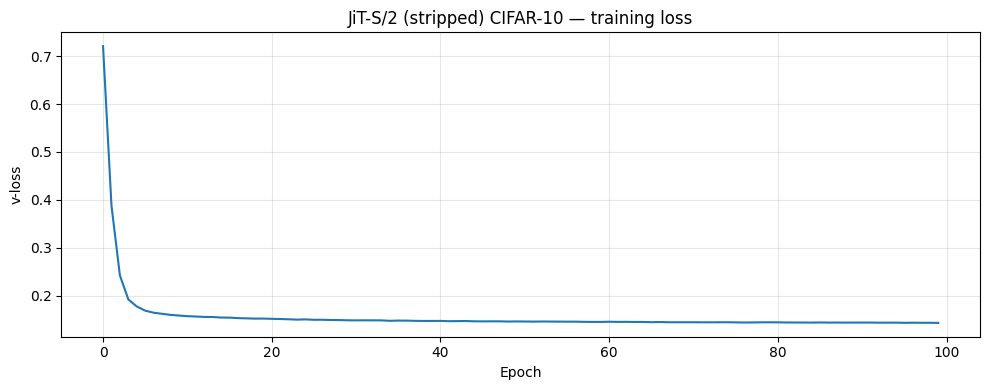

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("v-loss")
plt.title("JiT-S/2 (stripped) CIFAR-10 — training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Sample from EMA weights

No CFG means one network call per substep (Heun does two substeps per step, so 2 calls/step; the full-CFG version was 4 calls/step). Sampling is ~2× faster.


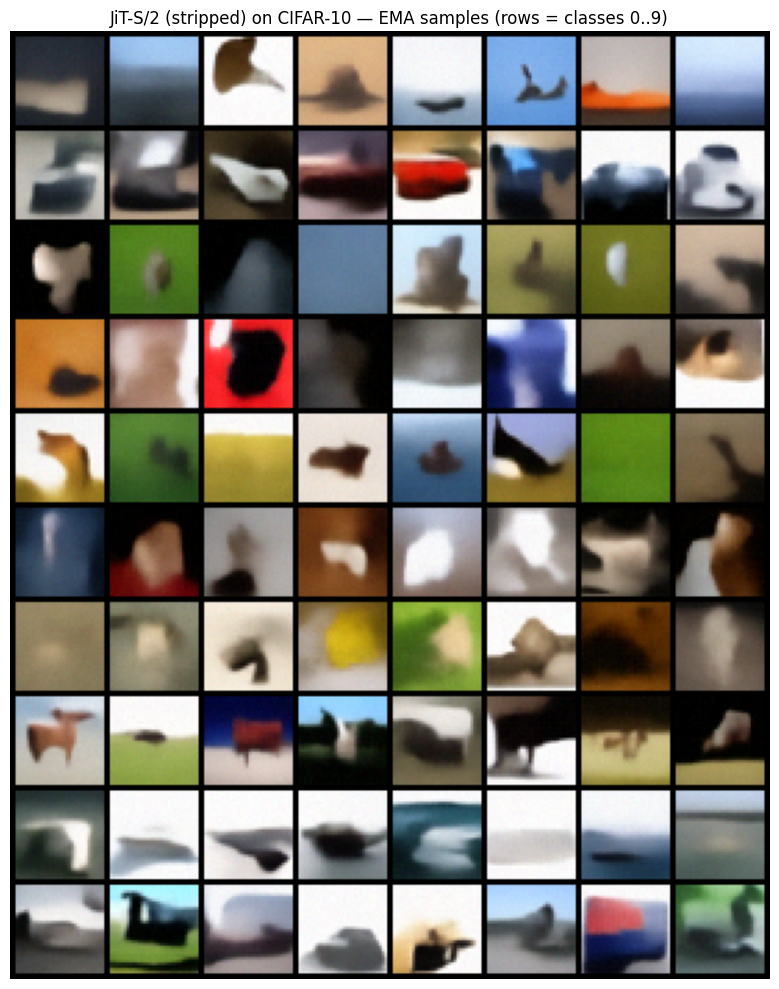

In [16]:
denoiser.eval()

N_PER_CLASS = 8
classes = torch.arange(NUM_CLASSES, device=device).repeat_interleave(N_PER_CLASS)

with denoiser.swap_ema(1):
    samples = denoiser.generate(classes, progress=True)

samples = ((samples.clamp(-1, 1) + 1) / 2).cpu()

grid = make_grid(samples, nrow=N_PER_CLASS, padding=2)
plt.figure(figsize=(N_PER_CLASS, NUM_CLASSES))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("JiT-S/2 (stripped) on CIFAR-10 — EMA samples (rows = classes 0..9)", fontsize=12)
plt.tight_layout()
plt.show()


## 15. Evaluation: FID + Inception Score, complexity, and throughput

Three blocks below:

1. **Dump images** — write 10K real CIFAR-10 images and 10K generated images to disk (under EMA weights).
2. **FID + IS** — use `torch-fidelity` (same evaluator the official JiT repo uses); fall back to `pytorch-fid` + `torchmetrics` if `torch-fidelity` isn't available.
3. **Complexity & throughput** — params, MACs (via `thop`), GFLOPs, inference throughput at batch 128, and end-to-end sampling throughput at batch 16 with 50 Heun steps.

Set `N_SAMPLES = 50000` for the official-style 50K FID/IS (slower); `10000` is the usual quick check.


### 15.1 Dump 10K real + 10K generated images to disk


In [17]:
import os
from torchvision.utils import save_image

REAL_DIR = "./fid_eval/real"
GEN_DIR  = "./fid_eval/generated"
os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(GEN_DIR,  exist_ok=True)

N_SAMPLES  = 10000        # set 50000 for official-style evaluation
BATCH_GEN  = 200

# ── 1) dump real CIFAR-10 images (from the same normalized dataset we trained on) ──
# Need raw [0,1] images on disk, so we de-normalize from [-1, 1].
print(f"Dumping {N_SAMPLES} real CIFAR-10 images to {REAL_DIR} ...")
written = 0
for img, _ in train_ds:
    if written >= N_SAMPLES:
        break
    save_image((img + 1) / 2, f"{REAL_DIR}/{written:05d}.png")
    written += 1
print(f"  ✅ {written} real images written")

# ── 2) generate samples under EMA weights ──
print(f"Generating {N_SAMPLES} samples (Heun {denoiser.steps} steps) to {GEN_DIR} ...")
denoiser.eval()
count = 0
with torch.no_grad(), denoiser.swap_ema(1):
    pbar = tqdm(total=N_SAMPLES, desc="Generating")
    while count < N_SAMPLES:
        bs = min(BATCH_GEN, N_SAMPLES - count)
        y  = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        imgs = denoiser.generate(y)
        imgs = ((imgs.clamp(-1, 1) + 1) / 2).cpu()
        for j in range(bs):
            save_image(imgs[j], f"{GEN_DIR}/{count + j:05d}.png")
        count += bs
        pbar.update(bs)
    pbar.close()
print(f"  ✅ {count} generated images written")


Dumping 10000 real CIFAR-10 images to ./fid_eval/real ...
  ✅ 10000 real images written
Generating 10000 samples (Heun 50 steps) to ./fid_eval/generated ...


Generating: 100%|██████████| 10000/10000 [2:02:17<00:00,  1.36it/s]

  ✅ 10000 generated images written


### 15.2 FID + IS

`torch-fidelity` is the evaluator the official JiT repo uses; it returns both FID and IS from a single call over the same image folders. If installation fails, the cell falls back to `pytorch-fid` for FID and `torchmetrics` for IS.


In [18]:
# Install once (silently).
import subprocess, sys, importlib

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Try torch-fidelity first — gives FID and IS in one call.
try:
    importlib.import_module("torch_fidelity")
except ImportError:
    try:
        _install("torch-fidelity")
        importlib.invalidate_caches()
    except Exception as e:
        print(f"torch-fidelity install failed: {e}")

USE_TF = False
try:
    import torch_fidelity
    USE_TF = True
except ImportError:
    pass

if USE_TF:
    print("Using torch-fidelity (same tool as the official JiT repo)\n")
    metrics = torch_fidelity.calculate_metrics(
        input1=GEN_DIR,
        input2=REAL_DIR,
        cuda=(device == "cuda"),
        isc=True,                       # Inception Score on input1 (generated)
        fid=True,                       # Frechet Inception Distance
        kid=False,
        verbose=False,
        samples_find_deep=False,
    )
    fid_value = metrics["frechet_inception_distance"]
    is_mean   = metrics["inception_score_mean"]
    is_std    = metrics["inception_score_std"]
else:
    print("Falling back to pytorch-fid + torchmetrics for IS\n")
    try: importlib.import_module("pytorch_fid")
    except ImportError: _install("pytorch-fid")
    try: importlib.import_module("torchmetrics")
    except ImportError: _install("torchmetrics[image]")

    from pytorch_fid import fid_score
    fid_value = fid_score.calculate_fid_given_paths(
        [REAL_DIR, GEN_DIR],
        batch_size=256, device=device, dims=2048,
    )

    # IS via torchmetrics: stream the generated images through it.
    from torchmetrics.image.inception import InceptionScore
    from PIL import Image
    import glob
    inception = InceptionScore(normalize=True).to(device)
    paths = sorted(glob.glob(f"{GEN_DIR}/*.png"))
    bsz = 100
    for i in range(0, len(paths), bsz):
        batch = []
        for p in paths[i:i+bsz]:
            img = torch.from_numpy(np.array(Image.open(p).convert("RGB"))).permute(2, 0, 1).float() / 255.0
            batch.append(img)
        batch = torch.stack(batch).to(device)
        inception.update(batch)
    is_mean, is_std = inception.compute()
    is_mean, is_std = float(is_mean), float(is_std)

print(f"{'='*50}")
print(f"  FID-{N_SAMPLES//1000}K:   {fid_value:.2f}")
print(f"  IS-{N_SAMPLES//1000}K:    {is_mean:.2f} ± {is_std:.2f}")
print(f"{'='*50}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.9 MB/s eta 0:00:00
Using torch-fidelity (same tool as the official JiT repo)



Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth


  FID-10K:   144.32
  IS-10K:    4.41 ± 0.12


### 15.3 Complexity & throughput

Params + MACs via `thop`, inference throughput at batch 128 (single forward pass), and end-to-end sampling throughput at batch 16 with the configured Heun steps.


In [19]:
import time, subprocess, sys, importlib

try:
    importlib.import_module("thop")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
from thop import profile

print("--- Complexity & Throughput ---")
net.eval()
denoiser.eval()

# ── 1) MACs and params via thop ──
dummy_x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
dummy_t = torch.rand(1, device=device)
dummy_y = torch.randint(0, NUM_CLASSES, (1,), device=device)
macs, params = profile(net, inputs=(dummy_x, dummy_t, dummy_y), verbose=False)
gflops = (macs * 2) / 1e9   # 1 MAC = 2 FLOPs

print(f"  Model:           JiT-S/2 stripped (depth {DEPTH}, hidden {HIDDEN}, no in-context, no CFG)")
print(f"  Parameters:      {params/1e6:.2f} M")
print(f"  MACs  (fwd):     {macs/1e9:.4f} G")
print(f"  GFLOPs (fwd):    {gflops:.4f} G")
print("-" * 50)

# ── 2) Inference throughput (single forward pass at batch 128) ──
INF_BSZ   = 128
N_ITERS   = 50
x_batch   = torch.randn(INF_BSZ, 3, IMG_SIZE, IMG_SIZE, device=device)
t_batch   = torch.rand(INF_BSZ, device=device)
y_batch   = torch.randint(0, NUM_CLASSES, (INF_BSZ,), device=device)

with torch.no_grad():
    for _ in range(5):
        net(x_batch, t_batch, y_batch)        # warmup
    if device == "cuda": torch.cuda.synchronize()
    start = time.time()
    for _ in range(N_ITERS):
        _ = net(x_batch, t_batch, y_batch)
    if device == "cuda": torch.cuda.synchronize()
    inf_img_per_sec = (N_ITERS * INF_BSZ) / (time.time() - start)

# ── 3) End-to-end sampling throughput (Heun, configured steps, batch 16) ──
SAMP_BSZ = 16
with torch.no_grad():
    y_bench = torch.randint(0, NUM_CLASSES, (SAMP_BSZ,), device=device)
    # warmup
    _ = denoiser.generate(y_bench, progress=False)
    if device == "cuda": torch.cuda.synchronize()
    start = time.time()
    _ = denoiser.generate(y_bench, progress=False)
    if device == "cuda": torch.cuda.synchronize()
    samp_time = time.time() - start
    samp_img_per_sec = SAMP_BSZ / samp_time

print(f"  Inference throughput (batch={INF_BSZ}):  {inf_img_per_sec:.0f} img/s")
print(f"  Sampling throughput  (batch={SAMP_BSZ}, {denoiser.steps} {denoiser.method} steps): "
      f"{samp_img_per_sec:.2f} img/s  ({samp_time:.2f}s for {SAMP_BSZ} images)")
print("=" * 50)


--- Complexity & Throughput ---
  Model:           JiT-S/2 stripped (depth 12, hidden 384, no in-context, no CFG)
  Parameters:      32.52 M
  MACs  (fwd):     5.4611 G
  GFLOPs (fwd):    10.9223 G
--------------------------------------------------
  Inference throughput (batch=128):  129 img/s
  Sampling throughput  (batch=16, 50 heun steps): 1.36 img/s  (11.74s for 16 images)
